# EEG 基础模型 mini 版：代码 + 逐步输出

简版方案的缩小实现。每一段先讲这段在做什么、为什么这么做，然后是代码，然后**立刻用真实数据跑一遍**打印输入输出形状。

数据流：edf 文件 → 每导联 z-score → 切成 [导联 C, 秒 T, 采样点 P] 的 token 网格 → 1D 卷积 stem 把每个 token 的 P 个点变成 d 维向量 → 加上电极坐标的 Fourier 编码 → 随机遮一半 token → criss-cross Transformer → 重建被遮 token 的波形 → 冻结骨干做线性探针。

数据：PhysioNet eegmmidb，109 人、64 导、160 Hz。预训练与探针训练用受试者 1–80，探针测试用 81–109，测试的人预训练没见过。

In [1]:
import dataclasses, math, time
from dataclasses import dataclass
from pathlib import Path

import mne
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.signal import welch
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
mne.set_log_level("ERROR")
torch.manual_seed(0)
print("torch", torch.__version__, " mps 可用:", torch.backends.mps.is_available())

torch 2.14.0  mps 可用: True


## 1. 配置

所有超参集中在一个 dataclass，改参数不改代码。几个关键量的关系：

- `fs=160`、`patch_sec=1` → 每个 token 是 1 秒 = **P = 160 个采样点**
- `window_sec=8` → 一个预训练样本是 8 秒 = **T = 8 个 token 长**，64 导联 → 一个样本 64 × 8 = 512 个 token
- `d_model=128` → 每个 token 进 Transformer 后是 128 维向量
- `n_heads=4` → criss-cross 下 2 个头看空间、2 个头看时间
- `prefix_S`：-1 全双向（默认预训练）、0 纯因果、0<S<T 前 S 秒双向之后因果
- `n_subjects`：冒烟测试用，只取前 n 个受试者

In [2]:
ROOT = Path("/Users/erqian/Desktop/util_udf/bci/eeg_fm_mini")
DATA_ROOT = Path("/Users/erqian/Desktop/util_udf/physionet.org/files/eegmmidb/1.0.0")


@dataclass
class Cfg:
    # ---------- 数据 ----------
    data_root: Path = DATA_ROOT
    cache_dir: Path = ROOT / "cache"                  # 切好的窗存 npz，第二次起直接读
    out_dir: Path = ROOT / "runs"                     # 每次训练一个子目录：ckpt.pt + log.txt
    exclude_subjects: tuple = (88, 92, 100)           # 这三人采样率是 128 Hz，跳过
    pretrain_subjects: tuple = tuple(range(1, 81))    # 预训练 + 探针训练：1–80
    probe_test_subjects: tuple = tuple(range(81, 110))  # 探针测试：81–109，预训练没见过
    n_subjects: int = 0           # 0 = 全部；>0 每组只取前 n 个，冒烟测试用
    fs: int = 160                 # 采样率，eegmmidb 原生 160 Hz，不重采样
    patch_sec: float = 1.0        # 每导联每 1 秒一个 token
    window_sec: int = 8           # 预训练窗口长度（秒）= T
    clip_sigma: float = 20.0      # z-score 后截到 ±20，防坏道尖峰

    # ---------- 模型 ----------
    d_model: int = 128            # token 向量维度 d
    n_layers: int = 4             # Transformer 层数
    n_heads: int = 4              # 注意力头数，criss-cross 下一半空间一半时间
    attn: str = "criss"           # "criss" | "flat"（平铺全注意力，作对照臂）
    rope: bool = True             # 时间头 Q/K 是否用 RoPE
    n_freq: int = 6               # 坐标 Fourier 编码每轴几把频率尺子
    ffn_mult: int = 4             # FFN 中间层 = 4d
    dropout: float = 0.0

    # ---------- 预训练 ----------
    mask_ratio: float = 0.5       # 遮掉 50% 的 token
    prefix_S: int = -1            # -1 全双向；0 纯因果；0<S<T 前缀掩码
    batch_size: int = 16
    epochs: int = 10
    lr: float = 3e-4
    weight_decay: float = 0.05
    warmup_steps: int = 200       # 前 200 步线性升 lr，之后余弦降
    seed: int = 0
    device: str = "auto"          # auto → mps > cuda > cpu

    # ---------- 探针 ----------
    probe_tmax: float = 4.0       # 提示出现后取 4 秒 = 4 个 token

    @property
    def P(self) -> int:           # 每 token 采样点数
        return int(self.fs * self.patch_sec)

    @property
    def T(self) -> int:           # 每窗 token 数
        return self.window_sec

    def subjects(self, which: str) -> list:
        base = self.pretrain_subjects if which == "train" else self.probe_test_subjects
        subs = [s for s in base if s not in self.exclude_subjects]
        return subs[: self.n_subjects] if self.n_subjects > 0 else subs

In [3]:
cfg = Cfg(n_subjects=3)           # 本 notebook 全程用 3 个受试者演示；跑全量改成 Cfg()
print(f"P = {cfg.P} 点/token   T = {cfg.T} token/窗   d = {cfg.d_model}   heads = {cfg.n_heads}")
print("预训练受试者:", cfg.subjects("train"))
print("探针测试受试者:", cfg.subjects("test"))

P = 160 点/token   T = 8 token/窗   d = 128   heads = 4
预训练受试者: [1, 2, 3]
探针测试受试者: [81, 82, 83]


## 2. 数据管线

### 2.1 读一个 run

一个 edf 文件 = 一个受试者的一次记录（1 或 2 分钟）。做四件事：

1. **标准化通道名**：edf 里写的是 `Fc5.`、`C3..` 这种带点的名字，`eegbci.standardize` 改成标准 `FC5`、`C3`
2. **挂电极坐标**：`colin27_1005` 模板给每个标准名一个头模型上的 3D 坐标（单位 m），乘 10 变成 dm，数值范围约 ±1，方便后面 Fourier 编码
3. **每导联 z-score**：减均值除标准差，各导联幅度拉到同一量级；再截到 ±20σ 防坏道
4. **取事件**：注释里的 T0 休息、T1 左手/双手、T2 右手/双脚，探针要用

返回 `x[C, N]`（C=64 导联，N=采样点总数）、`coords[C, 3]`、事件表。

In [4]:
MI_RUNS = (4, 8, 12)              # 这三个 run 是"想象左手 vs 想象右手"
_MONTAGE = None


def _montage():
    # 模板只加载一次，缓存到全局
    global _MONTAGE
    if _MONTAGE is None:
        _MONTAGE = mne.channels.make_standard_montage("colin27_1005")
    return _MONTAGE


def load_run(cfg: Cfg, subj: int, run: int):
    """返回 x[C,N]（已 z-score 截幅）、coords[C,3]（dm）、events[n,3]、事件名→编号字典。"""
    f = cfg.data_root / f"S{subj:03d}" / f"S{subj:03d}R{run:02d}.edf"
    raw = mne.io.read_raw_edf(f, preload=True)
    mne.datasets.eegbci.standardize(raw)               # 'Fc5.' → 'FC5'
    raw.set_montage(_montage())                         # 挂坐标
    assert int(raw.info["sfreq"]) == cfg.fs, (f, raw.info["sfreq"])
    x = raw.get_data().astype(np.float32)               # [C,N]，单位 V
    x = (x - x.mean(1, keepdims=True)) / (x.std(1, keepdims=True) + 1e-8)   # 每导联 z-score
    x = np.clip(x, -cfg.clip_sigma, cfg.clip_sigma)
    coords = np.array([c["loc"][:3] for c in raw.info["chs"]], dtype=np.float32) * 10  # m → dm
    events, ids = mne.events_from_annotations(raw)      # events 每行 [采样点, 0, 事件编号]
    return x, coords, events, ids

x       (64, 20000)   [导联 C, 采样点 N]， 125.0 秒
        均值≈0 方差≈1： -0.0 1.0   最大绝对值 7.8
coords  (64, 3)  单位 dm，范围 -0.89 ~ 1.42
        导联 0 坐标 (x,y,z) = [-0.789  0.514  0.63 ]
events  (30, 3)  事件编号 {'T0': 1, 'T1': 2, 'T2': 3}
        前 4 行 [采样点, 0, 编号]: [[0, 0, 1], [672, 0, 3], [1328, 0, 1], [2000, 0, 2]]


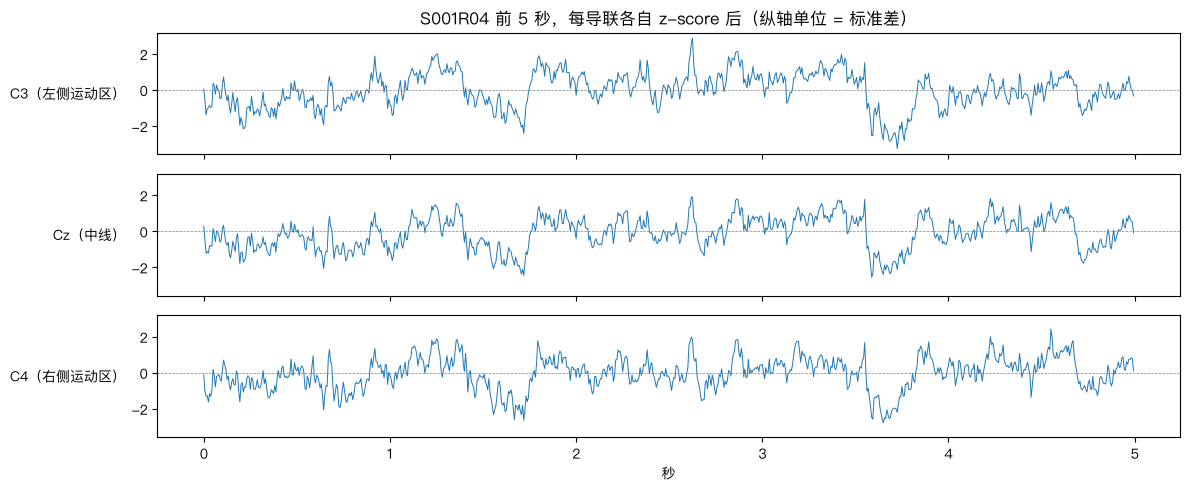

In [5]:
x, coords, events, ids = load_run(cfg, subj=1, run=4)
print("x      ", x.shape, "  [导联 C, 采样点 N]，", x.shape[1] / cfg.fs, "秒")
print("        均值≈0 方差≈1：", x.mean().round(3), x.std().round(3), "  最大绝对值", np.abs(x).max().round(1))
print("coords ", coords.shape, " 单位 dm，范围", coords.min().round(2), "~", coords.max().round(2))
print("        导联 0 坐标 (x,y,z) =", coords[0].round(3))
print("events ", events.shape, " 事件编号", ids)
print("        前 4 行 [采样点, 0, 编号]:", events[:4].tolist())

# 挑 C3 / Cz / C4 三根导联看前 5 秒：它们在中央区左 / 中 / 右，正好盖住手部运动皮层，
# 是运动想象任务 μ/β 节律变化最明显的位置（索引 8/10/12 是 eegbci.standardize 之后的顺序）
picks = {"C3（左侧运动区）": 8, "Cz（中线）": 10, "C4（右侧运动区）": 12}
t = np.arange(5 * cfg.fs) / cfg.fs
fig, axes = plt.subplots(len(picks), 1, figsize=(12, 5), sharex=True, sharey=True)
for ax, (name, ch) in zip(axes, picks.items()):
    ax.plot(t, x[ch, :5 * cfg.fs], lw=.7)
    ax.axhline(0, color="gray", lw=.5, ls="--")           # 0 = 该导联自己的均值
    ax.set_ylabel(name, rotation=0, ha="right", va="center")
axes[0].set_title("S001R04 前 5 秒，每导联各自 z-score 后（纵轴单位 = 标准差）")
axes[-1].set_xlabel("秒")
plt.tight_layout(); plt.show()


### 2.2 预训练数据：切成 [C, T, P] 的 token 网格

一个 run 的 `x[C, N]` 按 8 秒一段切开，每段 reshape 成 `[C, T=8, P=160]`：第 c 行第 t 列就是"导联 c 第 t 秒"这个 token 的 160 个采样点。全部 14 个 run 都用（预训练不需要标签）。

按受试者缓存成 npz，第二次起不再读 edf。`PretrainSet` 把所有受试者的窗拼起来，`__getitem__` 返回 `(x[C,T,P], coords[C,3])`。

In [6]:
def _cache_pretrain(cfg: Cfg, subj: int) -> Path:
    out = cfg.cache_dir / f"pre_S{subj:03d}.npz"
    if out.exists():
        return out
    cfg.cache_dir.mkdir(parents=True, exist_ok=True)
    wins, coords = [], None
    L = cfg.T * cfg.P                                   # 一窗多少采样点 = 8 × 160 = 1280
    for run in range(1, 15):                            # 14 个 run 全用
        x, coords, _, _ = load_run(cfg, subj, run)
        C, N = x.shape
        n = N // L                                      # 这个 run 能切几个整窗，尾巴丢掉
        if n == 0:
            continue
        # [C, n·L] → [C, n, T, P] → [n, C, T, P]
        wins.append(x[:, : n * L].reshape(C, n, cfg.T, cfg.P).transpose(1, 0, 2, 3))
    np.savez(out, x=np.concatenate(wins, 0), coords=coords)
    return out


class PretrainSet(Dataset):
    def __init__(self, cfg: Cfg, which: str = "train"):
        self.cfg = cfg
        xs, cs = [], []
        for s in cfg.subjects(which):
            z = np.load(_cache_pretrain(cfg, s))
            xs.append(z["x"])
            cs.append(np.repeat(z["coords"][None], len(z["x"]), 0))   # 同一人每个窗坐标相同
        self.x = np.concatenate(xs, 0)          # [N窗, C, T, P]
        self.coords = np.concatenate(cs, 0)     # [N窗, C, 3]

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return torch.from_numpy(self.x[i]), torch.from_numpy(self.coords[i])

窗数 582  x (582, 64, 8, 160)  [窗, C, T, P]   coords (582, 64, 3)
每窗 token 数 = C × T = 512   总 token 297984
内存 191 MB   （全量 77 人约 ×26）
ds[0] → (64, 8, 160) (64, 3) torch.float32


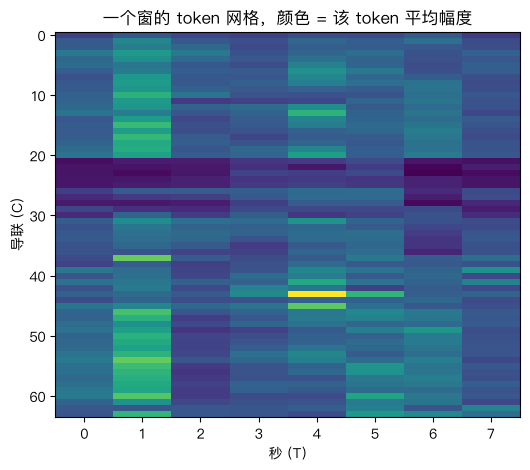

In [7]:
ds = PretrainSet(cfg, "train")
print("窗数", len(ds), " x", ds.x.shape, " [窗, C, T, P]   coords", ds.coords.shape)
print("每窗 token 数 = C × T =", ds.x.shape[1] * ds.x.shape[2], "  总 token", ds.x.shape[0] * ds.x.shape[1] * ds.x.shape[2])
print("内存", round(ds.x.nbytes / 1e6), "MB   （全量 77 人约 ×26）")
x0, c0 = ds[0]
print("ds[0] →", tuple(x0.shape), tuple(c0.shape), x0.dtype)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.abs(ds.x[0]).mean(-1), aspect="auto", cmap="viridis")
ax.set(xlabel="秒 (T)", ylabel="导联 (C)", title="一个窗的 token 网格，颜色 = 该 token 平均幅度")
plt.show()

### 2.3 探针数据：提示后 4 秒 + 左/右标签

只用 run 4/8/12。事件 T1 = 想象左手、T2 = 想象右手，T0 休息不要。从提示出现的采样点起取 4 秒 = 4 个 token，形状 `[C, 4, P]`，标签 0 左 1 右。这套数据**只给探针用，预训练看不到标签**。

In [8]:
def _cache_probe(cfg: Cfg, subj: int) -> Path:
    out = cfg.cache_dir / f"mi_S{subj:03d}.npz"
    if out.exists():
        return out
    cfg.cache_dir.mkdir(parents=True, exist_ok=True)
    xs, ys, coords = [], [], None
    n_tok = int(cfg.probe_tmax)                         # 4 个 token
    L = n_tok * cfg.P                                   # 640 个采样点
    for run in MI_RUNS:
        x, coords, events, ids = load_run(cfg, subj, run)
        for onset, _, code in events:
            if code == ids.get("T0"):                   # 休息段跳过
                continue
            seg = x[:, onset : onset + L]
            if seg.shape[1] < L:                        # 文件尾不够 4 秒的丢掉
                continue
            xs.append(seg.reshape(x.shape[0], n_tok, cfg.P))
            ys.append(0 if code == ids["T1"] else 1)    # T1 左 → 0，T2 右 → 1
    np.savez(out, x=np.stack(xs), y=np.array(ys, dtype=np.int64), coords=coords)
    return out


class ProbeSet(Dataset):
    def __init__(self, cfg: Cfg, which: str):
        xs, ys, cs, subj = [], [], [], []
        for s in cfg.subjects(which):
            z = np.load(_cache_probe(cfg, s))
            xs.append(z["x"]); ys.append(z["y"])
            cs.append(np.repeat(z["coords"][None], len(z["x"]), 0))
            subj += [s] * len(z["x"])
        self.x = np.concatenate(xs, 0)          # [N试次, C, 4, P]
        self.y = np.concatenate(ys, 0)          # [N试次]
        self.coords = np.concatenate(cs, 0)
        self.subj = np.array(subj)              # 每个试次属于谁，bootstrap 按人抽

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return torch.from_numpy(self.x[i]), torch.from_numpy(self.coords[i]), int(self.y[i])

In [9]:
ptr, pte = ProbeSet(cfg, "train"), ProbeSet(cfg, "test")
print("探针训练", ptr.x.shape, " 标签均值(右手占比)", ptr.y.mean().round(3), " 受试者", np.unique(ptr.subj))
print("探针测试", pte.x.shape, " 标签均值", pte.y.mean().round(3), " 受试者", np.unique(pte.subj))
print("每人试次数 ≈", len(ptr) // len(np.unique(ptr.subj)), "（3 run × 15 试次）")

探针训练 (135, 64, 4, 160)  标签均值(右手占比) 0.489  受试者 [1 2 3]
探针测试 (135, 64, 4, 160)  标签均值 0.504  受试者 [81 82 83]
每人试次数 ≈ 45 （3 run × 15 试次）


## 3. 模型

### 3.1 stem：160 个采样点 → 128 维向量

每个 token 是 1 秒 160 个点，要变成一个 d=128 的向量喂 Transformer。用三层 1D 卷积逐级压长度、升通道：

| 层 | 核 | 步长 | 长度 | 通道 |
|---|---|---|---|---|
| 输入 | | | 160 | 1 |
| Conv1 | 16 点 = 100 ms | 4 | 160 → 40 | 1 → 32 |
| Conv2 | 8 点 | 4 | 40 → 10 | 32 → 64 |
| Conv3 | 10 点 | 10 | 10 → 1 | 64 → 128 |

为什么不用一个 160 点的大核一步到位：那等价于一个 160×128 的线性层，丢掉了卷积的平移等变性（同一个波形出现在 token 的第 10 ms 和第 500 ms 应当被同样识别）。分层是让第一层看 100 ms 的局部形态，后面层组合。

所有 token 独立过 stem：`[B, C, T, P]` 先摊成 `[B·C·T, 1, P]`，卷完再摊回 `[B, C, T, d]`。

In [10]:
class ConvStem(nn.Module):
    """P 个采样点 → d 维。三层 1D 卷积，长度 P → 1，通道 1 → d。"""

    def __init__(self, P: int, d: int):
        super().__init__()
        assert P == 160, "stem 的步长按 160 点写死，换采样率要改 schedule"
        c1, c2 = d // 4, d // 2                      # 32, 64
        self.net = nn.Sequential(
            nn.Conv1d(1, c1, kernel_size=16, stride=4, padding=6), nn.GroupNorm(4, c1), nn.GELU(),   # 160 → 40
            nn.Conv1d(c1, c2, kernel_size=8, stride=4, padding=2), nn.GroupNorm(4, c2), nn.GELU(),    # 40 → 10
            nn.Conv1d(c2, d, kernel_size=10, stride=10),                                              # 10 → 1
        )

    def forward(self, x):                         # x[B,C,T,P]
        B, C, T, P = x.shape
        h = self.net(x.reshape(B * C * T, 1, P))  # 每个 token 独立卷 → [BCT, d, 1]
        return h.squeeze(-1).reshape(B, C, T, -1) # → [B, C, T, d]

In [11]:
stem = ConvStem(cfg.P, cfg.d_model)
print("stem 参数量", sum(p.numel() for p in stem.parameters()))

tok = x0[10, 2][None, None]                       # 导联 10、第 2 秒的 token → [1, 1, 160]
h = tok
print("\n单个 token 逐层：")
print(f"  输入        {tuple(h.shape)}  [batch, 通道, 长度]")
for layer in stem.net:
    h = layer(h)
    if isinstance(layer, nn.Conv1d):
        print(f"  Conv1d      {tuple(h.shape)}   核 {layer.kernel_size[0]} 点 = {layer.kernel_size[0]/cfg.fs*1000:.0f} ms，步长 {layer.stride[0]}")
print(f"  输出        {tuple(h.squeeze(-1).shape)}  → 这个 token 的 128 维向量")

xb = x0[None]                                     # 加 batch 维 → [1, C, T, P]
hw = stem(xb)
print(f"\n整窗：{tuple(xb.shape)} → {tuple(hw.shape)}   [B, C, T, d]")

stem 参数量 99232

单个 token 逐层：
  输入        (1, 1, 160)  [batch, 通道, 长度]
  Conv1d      (1, 32, 40)   核 16 点 = 100 ms，步长 4
  Conv1d      (1, 64, 10)   核 8 点 = 50 ms，步长 4
  Conv1d      (1, 128, 1)   核 10 点 = 62 ms，步长 10
  输出        (1, 128)  → 这个 token 的 128 维向量



整窗：(1, 64, 8, 160) → (1, 64, 8, 128)   [B, C, T, d]


### 3.2 电极坐标 Fourier 编码：3 个数 → 128 维

Transformer 本身不知道哪个 token 来自哪个电极。方案不查"电极名→向量"的表（换蒙太奇就失效），而是直接用电极的 3D 坐标算：

1. 每个坐标轴配 `n_freq=6` 把频率 π, 2π, 4π, …, 32π（等比翻倍，粗尺分大区域、细尺分毫米级）
2. 坐标 × 频率得角度，取 sin 和 cos → 每轴 2×6=12 个数，三轴 36 维
3. 一个线性层 36 → 128

结果是坐标的连续函数：新电极、新位置直接算，不用重训。两个电极离得近，它们的编码向量也近。

In [12]:
class FourierCoord(nn.Module):
    """coords[B,C,3] → [B,C,d]。每轴 n_freq 把频率取 sin/cos，拼成 6·n_freq 维后线性到 d。"""

    def __init__(self, d: int, n_freq: int):
        super().__init__()
        self.register_buffer("freqs", 2.0 ** torch.arange(n_freq) * math.pi)   # π, 2π, 4π ... 不是参数，不训练
        self.proj = nn.Linear(3 * 2 * n_freq, d)

    def forward(self, coords):
        ang = coords.unsqueeze(-1) * self.freqs               # [B,C,3,n_freq]  角度 = 坐标 × 频率
        feat = torch.cat([ang.sin(), ang.cos()], -1)          # [B,C,3,2·n_freq]
        return self.proj(feat.flatten(-2))                    # [B,C,6·n_freq] → [B,C,d]

频率尺子 [  3.14   6.28  12.57  25.13  50.27 100.53]
坐标 (1, 64, 3) → 角度 (1, 64, 3, 6) → sin/cos 特征 (1, 64, 36) → 线性 → (1, 64, 128)

导联 0：坐标 [-0.789  0.514  0.63 ]
        36 维特征前 6 个（x 轴 6 个 sin） [-0.615  0.97   0.471 -0.831 -0.924  0.707]
        128 维编码前 5 个 [ 0.553 -0.567 -1.016 -0.528  0.092]


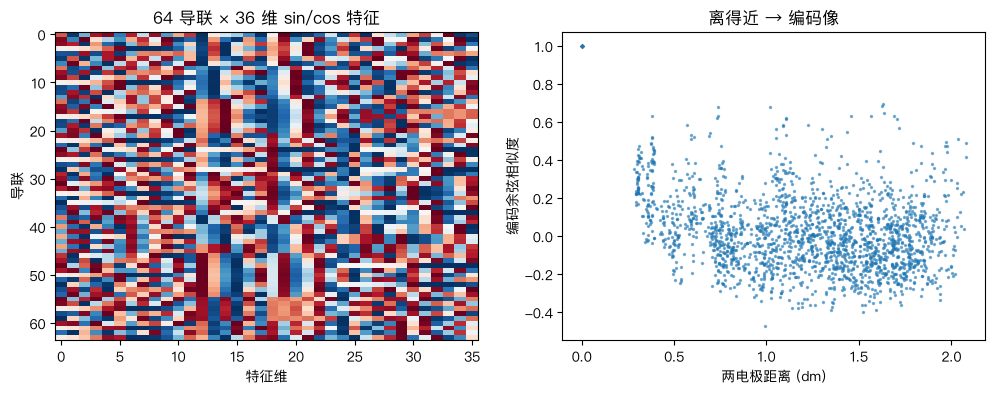

In [13]:
fc = FourierCoord(cfg.d_model, cfg.n_freq)
cb = c0[None]                                     # [1, C, 3]
ang = cb.unsqueeze(-1) * fc.freqs
feat = torch.cat([ang.sin(), ang.cos()], -1).flatten(-2)
pos = fc(cb)
print("频率尺子", fc.freqs.numpy().round(2))
print(f"坐标 {tuple(cb.shape)} → 角度 {tuple(ang.shape)} → sin/cos 特征 {tuple(feat.shape)} → 线性 → {tuple(pos.shape)}")
print("\n导联 0：坐标", c0[0].numpy().round(3))
print("        36 维特征前 6 个（x 轴 6 个 sin）", feat[0, 0, :6].numpy().round(3))
print("        128 维编码前 5 个", pos[0, 0, :5].detach().numpy().round(3))

dist = torch.cdist(cb[0], cb[0]).numpy()          # 电极两两物理距离
sim = F.cosine_similarity(feat[0][:, None], feat[0][None], dim=-1).numpy()
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].imshow(feat[0].numpy(), aspect="auto", cmap="RdBu"); axs[0].set(title="64 导联 × 36 维 sin/cos 特征", xlabel="特征维", ylabel="导联")
axs[1].scatter(dist.ravel(), sim.ravel(), s=2, alpha=.3); axs[1].set(xlabel="两电极距离 (dm)", ylabel="编码余弦相似度", title="离得近 → 编码像")
plt.show()

### 3.3 RoPE：时间位置转进 Q、K 的角度里

时间轴不加位置向量，而是在注意力打分前把 Q、K **按秒数旋转**。把 32 维的 head 向量看成 16 个二维平面，每个平面有自己的转速（快的分近距离、慢的分远距离），第 t 秒转 t × 转速 的角度。

旋转后 q·k 只取决于两者角度差 = 秒数差，所以模型学的是"隔几秒的两个 token 怎么互看"而不是"第几秒"，序列多长都能算。只用在时间头，空间头不用。

In [14]:
def rope(q, k, pos):
    """对最后一维成对旋转。q,k[..., L, hd]，pos[L] 是每个位置的秒数。"""
    hd = q.shape[-1]
    inv = 1.0 / (10000 ** (torch.arange(0, hd, 2, device=q.device).float() / hd))   # hd/2 把转速，等比递减
    ang = pos.float()[:, None] * inv[None]                    # [L, hd/2]  角度 = 秒数 × 转速
    sin, cos = ang.sin(), ang.cos()

    def rot(x):
        x1, x2 = x[..., 0::2], x[..., 1::2]                   # 偶数维、奇数维配对成二维点
        return torch.stack([x1 * cos - x2 * sin, x1 * sin + x2 * cos], -1).flatten(-2)   # 标准二维旋转

    return rot(q), rot(k)

In [15]:
hd = cfg.d_model // cfg.n_heads                   # 32
q = torch.randn(1, 1, 1, hd); k = torch.randn(1, 1, 1, hd)
inv = 1.0 / (10000 ** (torch.arange(0, hd, 2).float() / hd))
print("head 维", hd, "→", hd // 2, "个二维平面，转速（弧度/秒）前 4 个", inv[:4].numpy().round(4), "... 最后", inv[-1].item())

def score(tq, tk):
    qr, _ = rope(q, q, torch.tensor([tq]))        # q 转到第 tq 秒
    _, kr = rope(k, k, torch.tensor([tk]))        # k 转到第 tk 秒
    return (qr * kr).sum().item()

print("\n同一对 q、k：")
print(f"  q@3s  · k@5s   = {score(3, 5):.4f}")
print(f"  q@103s· k@105s = {score(103, 105):.4f}   ← 都隔 2 秒，打分相同")
print(f"  q@3s  · k@6s   = {score(3, 6):.4f}   ← 隔 3 秒，打分变了")

qt = torch.randn(2, 2, cfg.T, hd)
qr, kr = rope(qt, qt, torch.arange(cfg.T))
print(f"\n形状不变：{tuple(qt.shape)} → {tuple(qr.shape)}   模长不变：{qt[0,0,0].norm():.4f} → {qr[0,0,0].norm():.4f}")

head 维 32 → 16 个二维平面，转速（弧度/秒）前 4 个 [1.     0.5623 0.3162 0.1778] ... 最后 0.00017782794020604342

同一对 q、k：
  q@3s  · k@5s   = 2.2872
  q@103s· k@105s = 2.2871   ← 都隔 2 秒，打分相同
  q@3s  · k@6s   = 3.6357   ← 隔 3 秒，打分变了

形状不变：(2, 2, 8, 32) → (2, 2, 8, 32)   模长不变：5.8192 → 5.8192


### 3.4 criss-cross 注意力：一半头看同秒跨导联，一半头看同导联跨秒

token 排成 C×T 的格子。平铺全注意力是把 512 个 token 拉成一条让每个看所有，代价 (C·T)²，而且大部分"别的导联×别的秒"的格子相关性弱。criss-cross 把 4 个头分两组：

- **空间头**（前 2 个）：固定某一秒，沿导联方向做注意力。序列长 C=64，批次 B·T
- **时间头**（后 2 个）：固定某导联，沿时间方向做注意力。序列长 T=8，批次 B·C。Q、K 先过 RoPE，可加前缀掩码

实现就是 reshape：把要"沿着看"的那个轴放到序列位置，另一个轴并进 batch。两组输出拼回 `[B, C, T, d]` 再过输出投影。

`attn="flat"` 时走平铺分支作对照。

In [16]:
class CrissCrossAttention(nn.Module):
    def __init__(self, cfg: Cfg):
        super().__init__()
        d, H = cfg.d_model, cfg.n_heads
        assert d % H == 0 and H % 2 == 0
        self.H, self.hd, self.mode, self.use_rope = H, d // H, cfg.attn, cfg.rope
        self.qkv = nn.Linear(d, 3 * d)            # 一次算出 Q、K、V
        self.out = nn.Linear(d, d)
        self.drop = cfg.dropout

    def _attend(self, q, k, v, mask=None):
        # q,k,v [batch, heads, L, hd]；mask [L,L] bool，True=可见
        return F.scaled_dot_product_attention(q, k, v, attn_mask=mask, dropout_p=self.drop if self.training else 0.0)

    def forward(self, x, time_mask=None):        # x[B,C,T,d]
        B, C, T, d = x.shape
        q, k, v = self.qkv(x).reshape(B, C, T, 3, self.H, self.hd).unbind(3)   # 各 [B,C,T,H,hd]

        if self.mode == "flat":                   # 对照臂：C·T 个 token 拉平全看
            q, k, v = (t.reshape(B, C * T, self.H, self.hd).transpose(1, 2) for t in (q, k, v))
            mask = None if time_mask is None else time_mask.repeat(C, C)
            o = self._attend(q, k, v, mask).transpose(1, 2).reshape(B, C, T, d)
            return self.out(o)

        h = self.H // 2
        # 空间头：取前 h 个头，把 T 并进 batch，C 当序列 → [B·T, h, C, hd]
        qs, ks, vs = (t[..., :h, :].permute(0, 2, 3, 1, 4).reshape(B * T, h, C, self.hd) for t in (q, k, v))
        os_ = self._attend(qs, ks, vs).reshape(B, T, h, C, self.hd).permute(0, 3, 1, 2, 4)   # 回到 [B,C,T,h,hd]
        # 时间头：取后 h 个头，把 C 并进 batch，T 当序列 → [B·C, h, T, hd]
        qt, kt, vt = (t[..., h:, :].permute(0, 1, 3, 2, 4).reshape(B * C, h, T, self.hd) for t in (q, k, v))
        if self.use_rope:
            qt, kt = rope(qt, kt, torch.arange(T, device=x.device))
        ot = self._attend(qt, kt, vt, time_mask).reshape(B, C, h, T, self.hd).permute(0, 1, 3, 2, 4)
        return self.out(torch.cat([os_, ot], -2).reshape(B, C, T, d))   # 两组头拼回 d 维

输入 x            (1, 64, 8, 128)   [B, C, T, d]
qkv 线性后拆开     q (1, 64, 8, 4, 32)   [B, C, T, H, hd]
空间头 q          (8, 2, 64, 32)   [B·T, h, C, hd]  ← 序列长 C，同一秒 64 个导联互看
时间头 q          (64, 2, 8, 32)   [B·C, h, T, hd]  ← 序列长 T，同一导联 8 秒互看
输出              (1, 64, 8, 128)   形状和输入一样

空间头打分矩阵 (64, 64) 每行和 = 1.000    时间头打分矩阵 (8, 8)


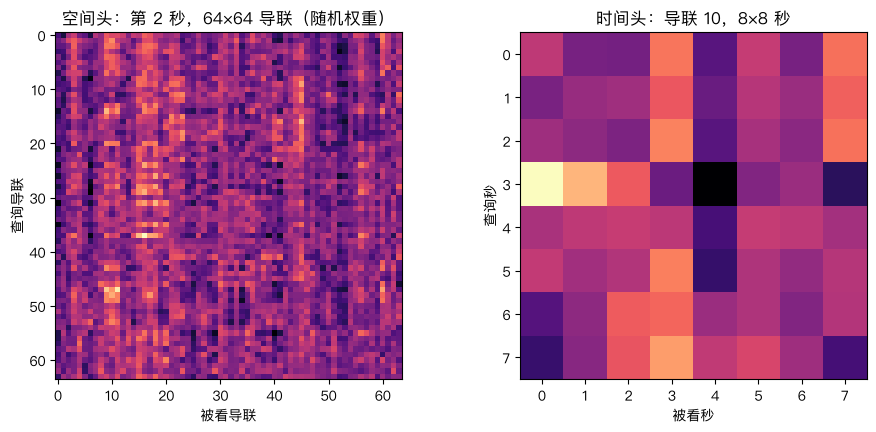

In [17]:
attn = CrissCrossAttention(cfg)
hin = hw + pos[:, :, None, :]                     # 3.5 会正式讲这一步：波形向量 + 坐标向量
B, C, T, d = hin.shape
q, k, v = attn.qkv(hin).reshape(B, C, T, 3, attn.H, attn.hd).unbind(3)
h = attn.H // 2
qs = q[..., :h, :].permute(0, 2, 3, 1, 4).reshape(B * T, h, C, attn.hd)
qt = q[..., h:, :].permute(0, 1, 3, 2, 4).reshape(B * C, h, T, attn.hd)
print(f"输入 x            {tuple(hin.shape)}   [B, C, T, d]")
print(f"qkv 线性后拆开     q {tuple(q.shape)}   [B, C, T, H, hd]")
print(f"空间头 q          {tuple(qs.shape)}   [B·T, h, C, hd]  ← 序列长 C，同一秒 64 个导联互看")
print(f"时间头 q          {tuple(qt.shape)}   [B·C, h, T, hd]  ← 序列长 T，同一导联 8 秒互看")
out = attn(hin)
print(f"输出              {tuple(out.shape)}   形状和输入一样")

# 手算一个空间头和一个时间头的注意力矩阵看看
A_space = torch.softmax(q[0, :, 2, 0] @ k[0, :, 2, 0].T / math.sqrt(attn.hd), -1)            # 第 2 秒、头 0
qt1, kt1 = rope(q[0, 10, :, h][None, None], k[0, 10, :, h][None, None], torch.arange(T))
A_time = torch.softmax(qt1[0, 0] @ kt1[0, 0].T / math.sqrt(attn.hd), -1)                      # 导联 10、时间头 0
print(f"\n空间头打分矩阵 {tuple(A_space.shape)} 每行和 = {A_space.sum(-1)[0]:.3f}    时间头打分矩阵 {tuple(A_time.shape)}")
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].imshow(A_space.detach(), cmap="magma"); axs[0].set(title="空间头：第 2 秒，64×64 导联（随机权重）", xlabel="被看导联", ylabel="查询导联")
axs[1].imshow(A_time.detach(), cmap="magma"); axs[1].set(title="时间头：导联 10，8×8 秒", xlabel="被看秒", ylabel="查询秒")
plt.show()

### 3.5 Transformer Block：Pre-LN + FFN 4d

一层 = 注意力子层 + FFN 子层，各带残差：

- `x = x + Attn(LN(x))`：先对进子层的那份做 LayerNorm，变换完加回残差。残差这条路不经过 LN，是恒等直通，深栈训练稳（Pre-LN；Post-LN 是 `LN(x + Attn(x))`）
- `x = x + FFN(LN(x))`：FFN 是逐 token 的两层 MLP，128 → 512 → 128，中间 GELU。注意力负责 token 之间换信息，FFN 负责每个 token 自己的特征变换

In [18]:
class Block(nn.Module):
    def __init__(self, cfg: Cfg):
        super().__init__()
        d = cfg.d_model
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = CrissCrossAttention(cfg)
        self.ffn = nn.Sequential(nn.Linear(d, cfg.ffn_mult * d), nn.GELU(), nn.Linear(cfg.ffn_mult * d, d), nn.Dropout(cfg.dropout))

    def forward(self, x, time_mask=None):
        x = x + self.attn(self.ln1(x), time_mask)     # 归一化只在分支里，残差旁路原样
        return x + self.ffn(self.ln2(x))

In [19]:
blk = Block(cfg)
n_attn = sum(p.numel() for p in blk.attn.parameters()); n_ffn = sum(p.numel() for p in blk.ffn.parameters())
print(f"一层参数：注意力 {n_attn}  FFN {n_ffn}  → FFN 占 {n_ffn / (n_attn + n_ffn):.0%}")
print(f"FFN 形状：{blk.ffn[0].in_features} → {blk.ffn[0].out_features} → {blk.ffn[2].out_features}")
h1 = blk(hin)
print(f"\nBlock 进 {tuple(hin.shape)} 出 {tuple(h1.shape)}")
print(f"残差流范数：进 {hin.norm(dim=-1).mean():.3f} → 出 {h1.norm(dim=-1).mean():.3f}（Pre-LN 下逐层累加，会慢慢涨）")

一层参数：注意力 66048  FFN 131712  → FFN 占 67%
FFN 形状：128 → 512 → 128

Block 进 (1, 64, 8, 128) 出 (1, 64, 8, 128)
残差流范数：进 6.473 → 出 7.171（Pre-LN 下逐层累加，会慢慢涨）


### 3.6 前缀掩码、整模型、随机掩码

**前缀掩码**是给时间头用的 `[T, T]` 可见矩阵：前 S 秒互相全可见，之后每秒只看自己和之前的。S=-1 不用掩码（全双向，默认预训练），S=0 纯因果。方案三期"一套权重、双向检测 + 因果预测"靠的就是这个开关。

**整模型 `EEGFM`**：
1. `stem(x)` → `[B,C,T,d]`
2. 被遮的 token 换成一个可学习的 `mask_token`（模型看不到原波形）
3. 加坐标编码（广播到每一秒）
4. 过 n_layers 个 Block，末尾 LayerNorm
5. `head`：128 → 160，把每个 token 的向量还原成 160 个采样点；只在被遮位置算 MSE

**`random_mask`**：每个样本随机选 50% 的 (导联, 秒) 格子遮掉。

**`features`**：探针用，不遮、对 C 和 T 平均池化 → `[B, d]`。

In [20]:
def prefix_mask(T: int, S: int, device):
    """[T,T] bool，True=可见。S<0 或 S>=T 返回 None（全双向）；S=0 纯因果；0<S<T 前缀。"""
    if S < 0 or S >= T:
        return None
    i = torch.arange(T, device=device)
    return (i[None, :] < S) | (i[None, :] <= i[:, None])       # 被看的秒 < S，或 被看的秒 <= 查询秒


class EEGFM(nn.Module):
    def __init__(self, cfg: Cfg):
        super().__init__()
        self.cfg = cfg
        d = cfg.d_model
        self.stem = ConvStem(cfg.P, d)
        self.coord = FourierCoord(d, cfg.n_freq)
        self.mask_token = nn.Parameter(torch.zeros(d))         # 被遮 token 的占位向量，可学习
        self.blocks = nn.ModuleList(Block(cfg) for _ in range(cfg.n_layers))
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, cfg.P)                        # 重建头：d → 160 个采样点
        nn.init.normal_(self.mask_token, std=0.02)

    def encode(self, x, coords, mask=None):
        """x[B,C,T,P], coords[B,C,3], mask[B,C,T] bool（True=遮）→ 表征 [B,C,T,d]。"""
        h = self.stem(x)
        if mask is not None:
            h = torch.where(mask[..., None], self.mask_token.to(h.dtype), h)   # 遮住的位置换 mask_token
        h = h + self.coord(coords)[:, :, None, :]              # 坐标 [B,C,1,d] 广播到每一秒
        tm = prefix_mask(x.shape[2], self.cfg.prefix_S, x.device)
        for blk in self.blocks:
            h = blk(h, tm)
        return self.ln_f(h)

    def forward(self, x, coords, mask):
        """返回被遮 token 上的重建 MSE。"""
        h = self.encode(x, coords, mask)
        pred = self.head(h)                                    # [B,C,T,P]
        return F.mse_loss(pred[mask], x[mask])                 # 只算被遮的

    @torch.no_grad()
    def features(self, x, coords):
        """冻结特征：不遮，对 C、T 平均池化 → [B,d]。"""
        return self.encode(x, coords).mean((1, 2))


def random_mask(B, C, T, ratio, device):
    """每个样本随机遮 ratio 比例的 (c,t) 格子 → [B,C,T] bool。"""
    n = int(round(C * T * ratio))
    idx = torch.rand(B, C * T, device=device).argsort(1)[:, :n]   # 随机打分取前 n 个
    m = torch.zeros(B, C * T, dtype=torch.bool, device=device)
    m.scatter_(1, idx, True)
    return m.reshape(B, C, T)

前缀掩码（行=查询秒，列=被看秒，■=可见）
S=-1 全双向
   全部可见
S= 0 纯因果
   ■·······
   ■■······
   ■■■·····
   ■■■■····
   ■■■■■···
   ■■■■■■··
   ■■■■■■■·
   ■■■■■■■■
S= 4 前 4 秒双向、之后因果
   ■■■■····
   ■■■■····
   ■■■■····
   ■■■■····
   ■■■■■···
   ■■■■■■··
   ■■■■■■■·
   ■■■■■■■■

整模型参数 0.918 M
mask (1, 64, 8)  遮了 256/512 个 token


encode  (1, 64, 8, 160) → 表征 (1, 64, 8, 128)
head    → 重建 (1, 64, 8, 160)   与输入同形
loss    被遮 token 上 MSE = 0.9452   （输入方差≈1，随机权重≈1 附近，训练后应明显低于 1）
features 探针特征 (1, 128)   [B, d]


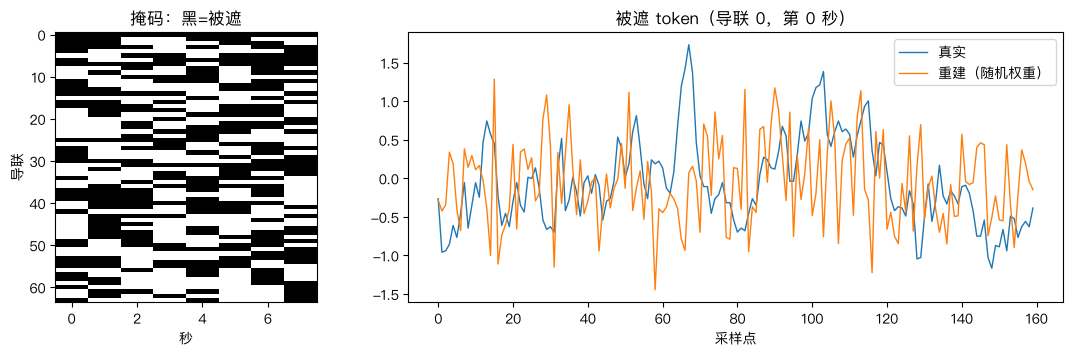

In [21]:
print("前缀掩码（行=查询秒，列=被看秒，■=可见）")
for S, name in ((-1, "全双向"), (0, "纯因果"), (4, "前 4 秒双向、之后因果")):
    m = prefix_mask(cfg.T, S, "cpu")
    print(f"S={S:>2} {name}")
    print("   全部可见" if m is None else "\n".join("   " + "".join("■" if v else "·" for v in row) for row in m.tolist()))

model = EEGFM(cfg)
print(f"\n整模型参数 {sum(p.numel() for p in model.parameters()) / 1e6:.3f} M")
mask = random_mask(1, C, T, cfg.mask_ratio, "cpu")
print(f"mask {tuple(mask.shape)}  遮了 {mask.sum().item()}/{mask.numel()} 个 token")

with torch.no_grad():
    rep = model.encode(xb, cb, mask)
    pred = model.head(rep)
    loss = model(xb, cb, mask)
    feat_vec = model.features(xb, cb)
print(f"encode  {tuple(xb.shape)} → 表征 {tuple(rep.shape)}")
print(f"head    → 重建 {tuple(pred.shape)}   与输入同形")
print(f"loss    被遮 token 上 MSE = {loss:.4f}   （输入方差≈1，随机权重≈1 附近，训练后应明显低于 1）")
print(f"features 探针特征 {tuple(feat_vec.shape)}   [B, d]")

ci, ti = mask[0].nonzero()[0].tolist()
fig, axs = plt.subplots(1, 2, figsize=(13, 3.5), gridspec_kw={"width_ratios": [1, 2.5]})
axs[0].imshow(mask[0].numpy(), aspect="auto", cmap="gray_r"); axs[0].set(title="掩码：黑=被遮", xlabel="秒", ylabel="导联")
axs[1].plot(xb[0, ci, ti], label="真实", lw=1); axs[1].plot(pred[0, ci, ti], label="重建（随机权重）", lw=1)
axs[1].set(title=f"被遮 token（导联 {ci}，第 {ti} 秒）", xlabel="采样点"); axs[1].legend()
plt.show()

## 4. 预训练

每步：取一个 batch `[16, 64, 8, 160]` → 随机遮 50% → 前向算被遮位置的 MSE → 反传 → 梯度裁剪到 1.0 → AdamW 更新。学习率前 `warmup_steps` 步线性升到 lr，之后余弦降到 0。每轮结束存 `runs/<tag>/ckpt.pt`。

`train()` 直接接收 Cfg，不走命令行。返回 loss 曲线方便画图。

In [22]:
def pick_device(name: str) -> torch.device:
    if name != "auto":
        return torch.device(name)
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def lr_at(step, total, cfg):
    """warmup 线性升，之后余弦降到 0。"""
    if step < cfg.warmup_steps:
        return cfg.lr * step / cfg.warmup_steps
    r = (step - cfg.warmup_steps) / max(1, total - cfg.warmup_steps)
    return cfg.lr * 0.5 * (1 + math.cos(math.pi * r))


def cfg_to_dict(cfg: Cfg) -> dict:
    """Path 转 str，保证 torch.save/load(weights_only=True) 能过。"""
    return {k: (str(v) if isinstance(v, Path) else v) for k, v in dataclasses.asdict(cfg).items()}


def cfg_from_dict(d: dict) -> Cfg:
    names = {f.name for f in dataclasses.fields(Cfg)}
    cfg = Cfg(**{k: v for k, v in d.items() if k in names})
    for k in ("data_root", "cache_dir", "out_dir"):
        setattr(cfg, k, Path(getattr(cfg, k)))
    return cfg


def train(cfg: Cfg, tag: str = "base", log_every: int = 50):
    torch.manual_seed(cfg.seed)
    dev = pick_device(cfg.device)
    out = cfg.out_dir / tag
    out.mkdir(parents=True, exist_ok=True)
    log = open(out / "log.txt", "a")

    def say(*a):
        s = " ".join(str(x) for x in a)
        print(s); log.write(s + "\n"); log.flush()

    ds = PretrainSet(cfg, "train")
    dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True, num_workers=0)
    say(f"windows {len(ds)}  tokens/epoch {len(ds) * ds.x.shape[1] * ds.x.shape[2] / 1e6:.1f}M  steps/epoch {len(dl)}  device {dev}")

    model = EEGFM(cfg).to(dev)
    say(f"params {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay, betas=(0.9, 0.95))
    total = cfg.epochs * len(dl)
    step, curve = 0, []

    for ep in range(cfg.epochs):
        model.train()
        t0, run = time.time(), 0.0
        for i, (x, coords) in enumerate(dl):
            x, coords = x.to(dev), coords.to(dev)                       # [16,64,8,160], [16,64,3]
            B, C, T, _ = x.shape
            mask = random_mask(B, C, T, cfg.mask_ratio, dev)            # [16,64,8]
            for g in opt.param_groups:
                g["lr"] = lr_at(step, total, cfg)
            loss = model(x, coords, mask)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            run += loss.item(); step += 1; curve.append(loss.item())
            if (i + 1) % log_every == 0:
                say(f"ep {ep} it {i + 1}/{len(dl)} loss {run / log_every:.4f} lr {lr_at(step, total, cfg):.2e} {(time.time() - t0) / (i + 1):.2f}s/it")
                run = 0.0
        torch.save({"cfg": cfg_to_dict(cfg), "model": model.state_dict(), "epoch": ep}, out / "ckpt.pt")
        say(f"== epoch {ep} done, {time.time() - t0:.0f}s, 本轮平均 loss {np.mean(curve[-len(dl):]):.4f}")
    return curve

下面用 3 个受试者训 2 轮冒烟，看 loss 从 ~1 往下走。跑全量改成 `Cfg()`（77 人、10 轮，M3 Pro 上约 2 分钟一轮）。

windows 582  tokens/epoch 0.3M  steps/epoch 36  device mps


params 0.92M


ep 0 it 10/36 loss 1.2453 lr 3.00e-04 0.18s/it


ep 0 it 20/36 loss 1.0508 lr 2.81e-04 0.15s/it


ep 0 it 30/36 loss 0.9830 lr 2.29e-04 0.14s/it


== epoch 0 done, 5s, 本轮平均 loss 1.0702


ep 1 it 10/36 loss 0.9028 lr 1.12e-04 0.12s/it


ep 1 it 20/36 loss 0.9759 lr 4.67e-05 0.12s/it


ep 1 it 30/36 loss 0.8327 lr 6.88e-06 0.12s/it


== epoch 1 done, 4s, 本轮平均 loss 0.8951


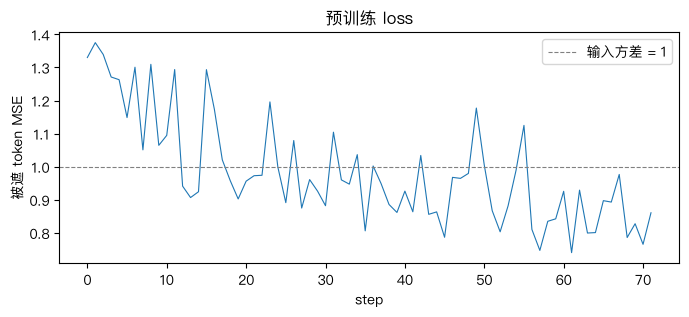

In [23]:
cfg_train = Cfg(n_subjects=3, epochs=2, warmup_steps=10)
curve = train(cfg_train, tag="nb_smoke", log_every=10)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(curve, lw=.8); ax.axhline(1.0, ls="--", c="gray", lw=.8, label="输入方差 = 1")
ax.set(xlabel="step", ylabel="被遮 token MSE", title="预训练 loss"); ax.legend(); plt.show()

## 5. 线性探针

骨干冻结不动，每个试次 `[64, 4, 160]` 过 `features()` 得 128 维向量，训一个逻辑回归分左右手。三行对照：

- **pretrained**：刚训好的权重
- **random**：同架构随机初始化。这是负控制——如果它和 pretrained 差不多，说明预训练没学到东西，是架构本身在起作用
- **bandpower**：每导联 μ(8–13 Hz)、β(13–30 Hz) 对数带功率 → 128 维手工特征。成熟基线，运动想象的标准做法

探针在受试者 1–80 上拟合，81–109 上测；置信区间按**受试者**bootstrap（把人整体抽，不把试次打散），因为同一个人的试次不独立。

In [24]:
@torch.no_grad()
def extract(model, ds, dev, bs=64):
    """整个数据集过 features → [N, d]。"""
    model.eval()
    feats = []
    for i in range(0, len(ds), bs):
        x = torch.from_numpy(ds.x[i : i + bs]).to(dev)
        c = torch.from_numpy(ds.coords[i : i + bs]).to(dev)
        feats.append(model.features(x, c).float().cpu().numpy())
    return np.concatenate(feats)


def bandpower(ds, fs):
    """每导联 μ/β 对数带功率 → [N, 2C]。"""
    x = ds.x.reshape(len(ds), ds.x.shape[1], -1)              # [N, C, 4·P] 拼回连续 4 秒
    f, pxx = welch(x, fs=fs, nperseg=fs, axis=-1)             # 功率谱，1 Hz 分辨率
    mu = pxx[..., (f >= 8) & (f < 13)].mean(-1)
    beta = pxx[..., (f >= 13) & (f < 30)].mean(-1)
    return np.log(np.stack([mu, beta], -1)).reshape(len(ds), -1)


def fit_eval(ftr, ytr, fte, yte, subj_te, seed=0):
    """标准化 + 逻辑回归；返回 acc 和按受试者 bootstrap 的 95% CI。"""
    clf = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000))
    clf.fit(ftr, ytr)
    pred = clf.predict(fte)
    acc = (pred == yte).mean()
    rng = np.random.default_rng(seed)
    subs = np.unique(subj_te)
    accs = []
    for _ in range(1000):
        pick = rng.choice(subs, len(subs), replace=True)       # 有放回抽人
        idx = np.concatenate([np.where(subj_te == s)[0] for s in pick])
        accs.append((pred[idx] == yte[idx]).mean())
    lo, hi = np.percentile(accs, [2.5, 97.5])
    return acc, lo, hi


def run_probe(tag: str = "base"):
    ck = torch.load(Cfg().out_dir / tag / "ckpt.pt", map_location="cpu")
    cfg = cfg_from_dict(ck["cfg"])
    cfg.prefix_S = -1                                          # 探针取双向表征
    dev = pick_device(cfg.device)

    tr, te = ProbeSet(cfg, "train"), ProbeSet(cfg, "test")
    print(f"probe train {len(tr)}  test {len(te)}  chance {max(te.y.mean(), 1 - te.y.mean()):.3f}")

    rows = []
    model = EEGFM(cfg).to(dev)
    model.load_state_dict(ck["model"])
    ftr, fte = extract(model, tr, dev), extract(model, te, dev)
    print(f"pretrained 特征 train {ftr.shape} test {fte.shape}")
    rows.append(("pretrained", *fit_eval(ftr, tr.y, fte, te.y, te.subj)))

    torch.manual_seed(cfg.seed + 1)
    rnd = EEGFM(cfg).to(dev)
    rows.append(("random", *fit_eval(extract(rnd, tr, dev), tr.y, extract(rnd, te, dev), te.y, te.subj)))

    bp_tr, bp_te = bandpower(tr, cfg.fs), bandpower(te, cfg.fs)
    print(f"bandpower 特征 train {bp_tr.shape} test {bp_te.shape}")
    rows.append(("bandpower", *fit_eval(bp_tr, tr.y, bp_te, te.y, te.subj)))

    print(f"\n{'feature':<12}{'acc':>8}{'95% CI':>18}")
    for name, acc, lo, hi in rows:
        print(f"{name:<12}{acc:>8.3f}    [{lo:.3f}, {hi:.3f}]")
    return rows

In [25]:
rows = run_probe("nb_smoke")

probe train 135  test 135  chance 0.504


pretrained 特征 train (135, 128) test (135, 128)


bandpower 特征 train (135, 128) test (135, 128)

feature          acc            95% CI
pretrained     0.489    [0.467, 0.511]
random         0.459    [0.400, 0.489]
bandpower      0.533    [0.489, 0.578]


读法：先看 `random` 那行。它不显著低于 `pretrained`，说明预训练没学到东西；显著低于，才轮到跟 `bandpower` 比。3 人 2 轮的数字没有意义，只是把链路走通。

## 6. 消融臂

同一份代码换参数就是方案里的对照臂：

| 臂 | 参数 | 验什么 |
|---|---|---|
| 平铺全注意力 | `Cfg(attn="flat")` | criss-cross 是否优于平铺 |
| 纯因果 | `Cfg(prefix_S=0)` | 因果比双向掉多少 |
| 前缀掩码 4 秒 | `Cfg(prefix_S=4)` | 一套权重两个出口是否可行 |
| 关 RoPE | `Cfg(rope=False)` | 时间位置信息值多少 |

每臂 `train(cfg, tag=...)` 后 `run_probe(tag)`，比三行结果。

## 7. 逐层走读：每一层吃进什么、吐出什么

前面各节把模块逐个定义完，这一节按数据流的顺序把它们串起来：读 run → 切成 token 网格 → stem → 坐标编码 → 相加 → 掩码 → RoPE → 前缀掩码 → criss-cross 注意力 → 整模型重建。每个 cell 只做一步，打印形状、画一张图；用到的类和函数都是前面定义过的，不再重复。

### 7.1 读一个 run：波形、坐标、事件

x      (64, 20000)   [导联, 采样点]，已按导联 z-score
coords (64, 3)  单位 dm，范围 -0.89 ~ 1.42
events (30, 3) {'T0': 1, 'T1': 2, 'T2': 3}   前 3 个： [[0, 0, 1], [672, 0, 3], [1328, 0, 1]]


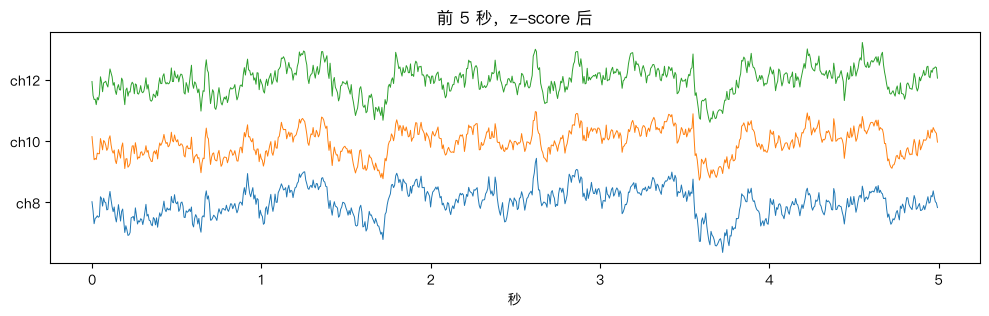

In [26]:
x, coords, events, ids = load_run(cfg, subj=1, run=4)
print('x     ', x.shape, '  [导联, 采样点]，已按导联 z-score')
print('coords', coords.shape, ' 单位 dm，范围', coords.min().round(2), '~', coords.max().round(2))
print('events', events.shape, ids, '  前 3 个：', events[:3].tolist())

fig, ax = plt.subplots(figsize=(12, 3))
t = np.arange(5 * cfg.fs) / cfg.fs
for i, ch in enumerate([8, 10, 12]):          # C3 / Cz / C4 附近
    ax.plot(t, x[ch, :5 * cfg.fs] + 4 * i, lw=.7)
ax.set(xlabel='秒', yticks=[0, 4, 8], yticklabels=['ch8', 'ch10', 'ch12'], title='前 5 秒，z-score 后')
plt.show()

### 7.2 切成 [C, T, P]：每导联每秒一个 token

一个 8 秒窗 → (64, 8, 160)  共 512 个 token，每个 160 个采样点


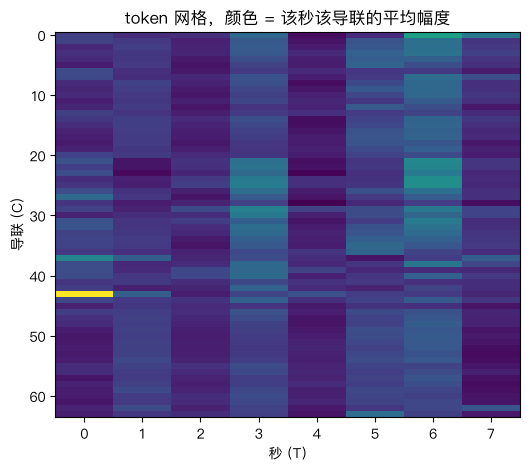

In [27]:
L = cfg.T * cfg.P
win = x[:, :L].reshape(x.shape[0], cfg.T, cfg.P)          # [C,T,P]
print('一个 8 秒窗 →', win.shape, ' 共', win.shape[0] * win.shape[1], '个 token，每个', win.shape[2], '个采样点')

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.abs(win).mean(-1), aspect='auto', cmap='viridis')
ax.set(xlabel='秒 (T)', ylabel='导联 (C)', title='token 网格，颜色 = 该秒该导联的平均幅度')
plt.show()

### 7.3 stem：160 个采样点 → 128 维向量，看每层的中间形状

In [28]:
stem = ConvStem(cfg.P, cfg.d_model)
tok = torch.from_numpy(win[10, 2])[None, None]             # 导联 10、第 2 秒 → [1, 1, 160]
h = tok
print('输入      ', tuple(h.shape), ' [batch, 通道, 长度]')
for layer in stem.net:
    h = layer(h)
    if isinstance(layer, torch.nn.Conv1d):
        print(f'{layer.__class__.__name__:<10}', tuple(h.shape), f'  核 {layer.kernel_size[0]} 点 = {layer.kernel_size[0]/cfg.fs*1000:.0f} ms, 步长 {layer.stride[0]}')
print('输出      ', tuple(h.squeeze(-1).shape), ' → 一个 token 的向量')

# 整窗一起过：[B,C,T,P] → [B,C,T,d]
hw = stem(torch.from_numpy(win)[None])
print('\n整窗', tuple(torch.from_numpy(win)[None].shape), '→', tuple(hw.shape))

输入       (1, 1, 160)  [batch, 通道, 长度]
Conv1d     (1, 32, 40)   核 16 点 = 100 ms, 步长 4
Conv1d     (1, 64, 10)   核 8 点 = 50 ms, 步长 4
Conv1d     (1, 128, 1)   核 10 点 = 62 ms, 步长 10
输出       (1, 128)  → 一个 token 的向量



整窗 (1, 64, 8, 160) → (1, 64, 8, 128)


### 7.4 坐标 Fourier 编码：3 个数 → 36 维 sin/cos → 128 维

频率（每轴几把尺子） [  3.14   6.28  12.57  25.13  50.27 100.53]    n_freq = 6
坐标 (1, 64, 3) → sin/cos 特征 (1, 64, 36) → 线性 → (1, 64, 128)

导联 0 的坐标 [-0.789  0.514  0.63 ] 
它的 36 维特征前 6 个 [-0.615  0.97   0.471 -0.831 -0.924  0.707]


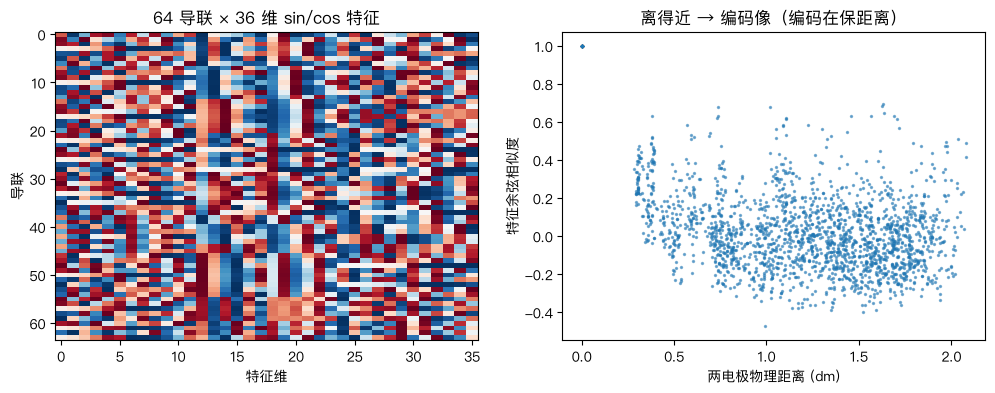

In [29]:
fc = FourierCoord(cfg.d_model, cfg.n_freq)
c = torch.from_numpy(coords)[None]                          # [1, C, 3]
ang = c.unsqueeze(-1) * fc.freqs                            # [1, C, 3, n_freq]
feat = torch.cat([ang.sin(), ang.cos()], -1).flatten(-2)    # [1, C, 6·n_freq]
pos = fc(c)                                                 # [1, C, d]
print('频率（每轴几把尺子）', fc.freqs.numpy().round(2), '   n_freq =', cfg.n_freq)
print('坐标', tuple(c.shape), '→ sin/cos 特征', tuple(feat.shape), '→ 线性 →', tuple(pos.shape))
print('\n导联 0 的坐标', coords[0].round(3), '\n它的 36 维特征前 6 个', feat[0, 0, :6].numpy().round(3))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].imshow(feat[0].numpy(), aspect='auto', cmap='RdBu'); axs[0].set(title='64 导联 × 36 维 sin/cos 特征', xlabel='特征维', ylabel='导联')
dist = np.linalg.norm(coords[:, None] - coords[None], axis=-1)
sim = F.cosine_similarity(feat[0][:, None], feat[0][None], dim=-1).numpy()
axs[1].scatter(dist.ravel(), sim.ravel(), s=2, alpha=.3); axs[1].set(xlabel='两电极物理距离 (dm)', ylabel='特征余弦相似度', title='离得近 → 编码像（编码在保距离）')
plt.show()

### 7.5 相加：波形向量 + 坐标向量，形状不变

In [30]:
h_in = hw + pos[:, :, None, :]                               # 坐标广播到每一秒
print('stem 输出', tuple(hw.shape), '+ 坐标', tuple(pos[:, :, None, :].shape), '(广播) →', tuple(h_in.shape))
print('同一导联不同秒，坐标部分相同；不同导联同一秒，波形部分不同')

stem 输出 (1, 64, 8, 128) + 坐标 (1, 64, 1, 128) (广播) → (1, 64, 8, 128)
同一导联不同秒，坐标部分相同；不同导联同一秒，波形部分不同


### 7.6 掩码：随机遮 50% 的 token，被遮的换成 mask_token

mask (1, 64, 8)  遮了 256 / 512 个 token


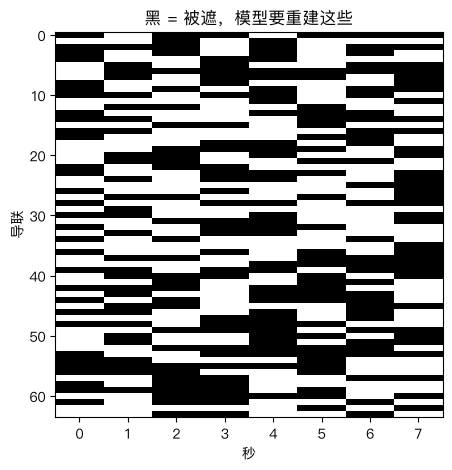

In [31]:
mask = random_mask(1, *win.shape[:2], cfg.mask_ratio, 'cpu')
print('mask', tuple(mask.shape), ' 遮了', mask.sum().item(), '/', mask.numel(), '个 token')
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mask[0].numpy(), aspect='auto', cmap='gray_r'); ax.set(xlabel='秒', ylabel='导联', title='黑 = 被遮，模型要重建这些')
plt.show()

### 7.7 RoPE：打分只跟相对秒差有关

q 在 3 秒、k 在 5 秒 ： -0.8274
q 在 103 秒、k 在 105 秒： -0.8273   ← 相差都是 2 秒，打分相同
q 在 3 秒、k 在 6 秒 ： -0.3386   ← 相差 3 秒，打分变了


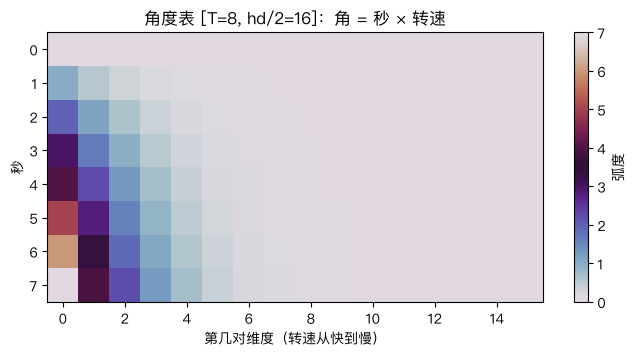

In [32]:
hd = cfg.d_model // cfg.n_heads
q = torch.randn(1, 1, 1, hd); k = torch.randn(1, 1, 1, hd)      # 同一对 q、k
def score(tq, tk):
    qr, _ = rope(q, q, torch.tensor([tq]))          # q 转到 tq 秒
    _, kr = rope(k, k, torch.tensor([tk]))          # k 转到 tk 秒
    return (qr * kr).sum().item()
print('q 在 3 秒、k 在 5 秒 ：', round(score(3, 5), 4))
print('q 在 103 秒、k 在 105 秒：', round(score(103, 105), 4), '  ← 相差都是 2 秒，打分相同')
print('q 在 3 秒、k 在 6 秒 ：', round(score(3, 6), 4), '  ← 相差 3 秒，打分变了')

inv = 1.0 / (10000 ** (torch.arange(0, hd, 2).float() / hd))
angs = torch.arange(cfg.T).float()[:, None] * inv[None]
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(angs.numpy(), aspect='auto', cmap='twilight'); plt.colorbar(im, label='弧度')
ax.set(xlabel='第几对维度（转速从快到慢）', ylabel='秒', title=f'角度表 [T={cfg.T}, hd/2={hd//2}]：角 = 秒 × 转速')
plt.show()

### 7.8 前缀掩码：时间头能看谁

In [33]:
for S in (-1, 0, 4):
    m = prefix_mask(cfg.T, S, 'cpu')
    print(f'S={S:>2} ({"全双向" if S<0 else "纯因果" if S==0 else "前缀 4 秒双向、之后因果"})')
    print('   全部可见' if m is None else '\n'.join('   ' + ''.join('■' if v else '·' for v in row) for row in m.tolist()))
print('行 = 查询秒，列 = 被看的秒，■ = 可见')

S=-1 (全双向)
   全部可见
S= 0 (纯因果)
   ■·······
   ■■······
   ■■■·····
   ■■■■····
   ■■■■■···
   ■■■■■■··
   ■■■■■■■·
   ■■■■■■■■
S= 4 (前缀 4 秒双向、之后因果)
   ■■■■····
   ■■■■····
   ■■■■····
   ■■■■····
   ■■■■■···
   ■■■■■■··
   ■■■■■■■·
   ■■■■■■■■
行 = 查询秒，列 = 被看的秒，■ = 可见


### 7.9 criss-cross 注意力：空间头看同秒跨导联，时间头看同导联跨秒

已加载预训练权重 runs/base
空间头打分矩阵 (64, 64) （同一秒、导联对导联）
时间头打分矩阵 (8, 8) （同一导联、秒对秒）


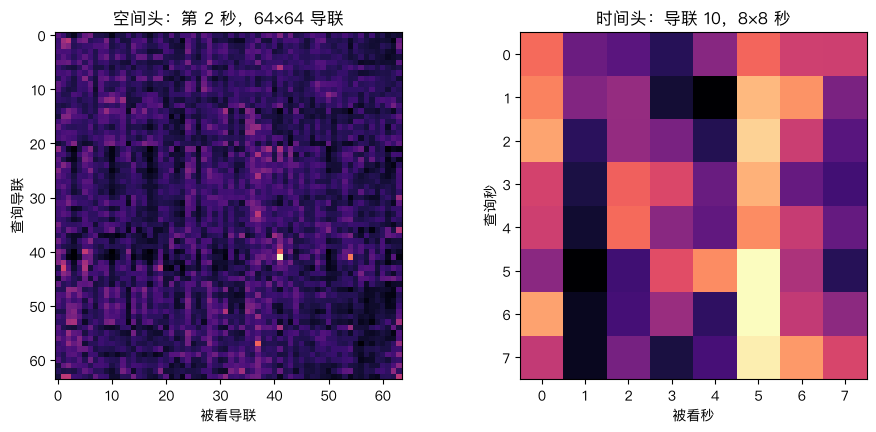

一个 Block 进出 (1, 64, 8, 128) → (1, 64, 8, 128)


In [34]:
model = EEGFM(cfg).eval()
import pathlib
ck = pathlib.Path(cfg.out_dir) / 'base' / 'ckpt.pt'
if ck.exists():
    model.load_state_dict(torch.load(ck, map_location='cpu')['model']); print('已加载预训练权重 runs/base')
else:
    print('runs/base 还没训，用随机初始化演示形状')

blk = model.blocks[0]; attn = blk.attn
xin = blk.ln1(h_in)
B, C, T, d = xin.shape
qkv = attn.qkv(xin).reshape(B, C, T, 3, attn.H, attn.hd)
q_, k_ = qkv[..., 0, :, :], qkv[..., 1, :, :]
hh = attn.H // 2
# 空间头 0，第 2 秒：C×C 打分
qs, ks = q_[0, :, 2, 0], k_[0, :, 2, 0]
A_space = torch.softmax(qs @ ks.T / math.sqrt(attn.hd), -1)
# 时间头（第 hh 个头），导联 10：T×T 打分，带 RoPE
qt, kt = q_[0, 10, :, hh][None, None], k_[0, 10, :, hh][None, None]
qt, kt = rope(qt, kt, torch.arange(T))
A_time = torch.softmax((qt[0, 0] @ kt[0, 0].T) / math.sqrt(attn.hd), -1)
print('空间头打分矩阵', tuple(A_space.shape), '（同一秒、导联对导联）')
print('时间头打分矩阵', tuple(A_time.shape), '（同一导联、秒对秒）')
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].imshow(A_space.detach(), cmap='magma'); axs[0].set(title='空间头：第 2 秒，64×64 导联', xlabel='被看导联', ylabel='查询导联')
axs[1].imshow(A_time.detach(), cmap='magma'); axs[1].set(title='时间头：导联 10，8×8 秒', xlabel='被看秒', ylabel='查询秒')
plt.show()
out = blk(h_in); print('一个 Block 进出', tuple(h_in.shape), '→', tuple(out.shape))

### 7.10 整模型：重建被遮 token

表征 (1, 64, 8, 128)  重建 (1, 64, 8, 160)  被遮 token 上 MSE = 0.2105 （输入方差≈1，随机模型≈1）


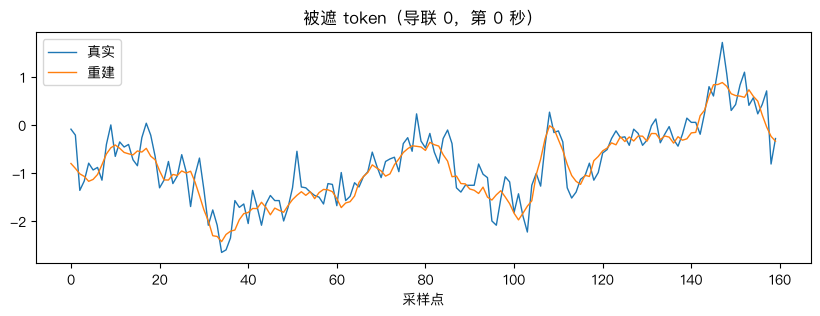

探针用的冻结特征：对 C、T 平均池化 → (1, 128)


In [35]:
xb = torch.from_numpy(win)[None]
with torch.no_grad():
    hrep = model.encode(xb, c, mask)
    pred = model.head(hrep)
    loss = F.mse_loss(pred[mask], xb[mask])
print('表征', tuple(hrep.shape), ' 重建', tuple(pred.shape), ' 被遮 token 上 MSE =', round(loss.item(), 4), '（输入方差≈1，随机模型≈1）')

ci, ti = mask[0].nonzero()[0].tolist()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(xb[0, ci, ti], label='真实', lw=1); ax.plot(pred[0, ci, ti], label='重建', lw=1)
ax.set(title=f'被遮 token（导联 {ci}，第 {ti} 秒）', xlabel='采样点'); ax.legend(); plt.show()

feat_vec = model.features(xb, c)
print('探针用的冻结特征：对 C、T 平均池化 →', tuple(feat_vec.shape))